In [1]:
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.ipc as ipc
import time
import os
import io
import tempfile
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
BASE_DIR = Path.cwd().parent
RESULTS_DIR = (
BASE_DIR /
"results" /
"batch_effects"
)
GRAPHS_DIR = RESULTS_DIR / "graphs"
TABLES_DIR = RESULTS_DIR / "tables"
LOGS_DIR = RESULTS_DIR / "logs"
GRAPHS_DIR.mkdir(
parents=True,
exist_ok=True
)
TABLES_DIR.mkdir(
parents=True,
exist_ok=True
)
LOGS_DIR.mkdir(
parents=True,
exist_ok=True
)
print(f"Results directory: {RESULTS_DIR}")

Results directory: /home/megh/arrow-ipc-analysis-linux/results/batch_effects


In [3]:
print("\n" + "="*80)
print("BATCH EFFECTS EXPERIMENT")
print("="*80)
TOTAL_ROWS = 1_000_000
BATCH_SIZES = [
1_000,
10_000,
50_000,
100_000,
250_000,
500_000,
1_000_000
]
print(f"Total rows : {TOTAL_ROWS:,}")
print(f"Batch sizes : {BATCH_SIZES}")
print(f"Output directory: {RESULTS_DIR}")



BATCH EFFECTS EXPERIMENT
Total rows : 1,000,000
Batch sizes : [1000, 10000, 50000, 100000, 250000, 500000, 1000000]
Output directory: /home/megh/arrow-ipc-analysis-linux/results/batch_effects


In [4]:
print("\n" + "="*80)
print("CREATING SYNTHETIC DATASET")
print("="*80)
np.random.seed(42)
3
df = pd.DataFrame({
"feature_1": np.random.randn(TOTAL_ROWS),
"feature_2": np.random.randn(TOTAL_ROWS),
"feature_3": np.random.randint(
0,
1000,
TOTAL_ROWS
),
"feature_4": np.random.rand(TOTAL_ROWS),
"category": np.random.choice(
["A", "B", "C", "D"],
TOTAL_ROWS
)
})
print(df.head())
print(f"\nDataset shape: {df.shape}")


CREATING SYNTHETIC DATASET
   feature_1  feature_2  feature_3  feature_4 category
0   0.496714   0.169172        639   0.486056        D
1  -0.138264  -0.121505        585   0.649509        D
2   0.647689   1.156625        445   0.377894        B
3   1.523030   0.200086        732   0.355518        B
4  -0.234153   0.864611        999   0.295414        A

Dataset shape: (1000000, 5)


In [5]:
print("\n" + "="*80)
print("CONVERTING TO ARROW TABLE")
print("="*80)
table = pa.Table.from_pandas(df)
print(table.schema)


CONVERTING TO ARROW TABLE
feature_1: double
feature_2: double
feature_3: int64
feature_4: double
category: large_string
-- schema metadata --
pandas: '{"index_columns": [{"kind": "range", "name": null, "start": 0, "' + 866


In [6]:
def serialize_with_batch_size(batch_size):
    # ------------------------------------------
    # Split into batches
    # ------------------------------------------
    batches = table.to_batches(
    max_chunksize=batch_size
    )
    # ------------------------------------------
    # Serialize
    # ------------------------------------------
    sink = io.BytesIO()
    writer = ipc.new_stream(
        sink,
        table.schema
    )
    start = time.perf_counter()
    for batch in batches:
        writer.write_batch(batch)
    writer.close()
    serialization_time = (
        time.perf_counter() - start
    )
    serialized_data = sink.getvalue()
    payload_size_mb = (
        len(serialized_data) /
        (1024 ** 2)
    )
    # ------------------------------------------
    # Deserialize
    # ------------------------------------------
    start = time.perf_counter()
    reader = ipc.open_stream(serialized_data)
    recovered_batches = []
    while True:
        try:
            recovered_batches.append(
            reader.read_next_batch()
            )
        except StopIteration:
            break
    deserialization_time = (
        time.perf_counter() - start
    )
    # ------------------------------------------
    # Average serialization cost
    # ------------------------------------------
    average_batch_time = (
        serialization_time /
        len(batches)
    )
    return {
        "Batch_Size": batch_size,
        "Num_Batches": len(batches),
        "Serialization_Time_s": serialization_time,
        "Deserialization_Time_s": deserialization_time,
        "Payload_Size_MB": payload_size_mb,
        "Average_Batch_Time_ms": (
        average_batch_time * 1000
    )
    }


In [8]:
print("\n" + "="*80)
print("RUNNING BATCH SIZE EXPERIMENTS")
print("="*80)
results = []
for batch_size in BATCH_SIZES:
    print("\n" + "-"*80)
    print(f"Testing batch size: {batch_size:,}")
    print("-"*80)
    result = serialize_with_batch_size(
    batch_size
    )
    results.append(result)
    print(
    f"Batches : {result['Num_Batches']}"
    )
    print(
    f"Serialization Time : "
    f"{result['Serialization_Time_s']:.6f}s"
    )
    print(
    f"Deserialization Time : "
    f"{result['Deserialization_Time_s']:.6f}s"
    )
    print(
    f"Payload Size : "
    f"{result['Payload_Size_MB']:.2f} MB"
    )
    print(
    f"Average Batch Cost : "
    f"{result['Average_Batch_Time_ms']:.4f} ms"
    )


RUNNING BATCH SIZE EXPERIMENTS

--------------------------------------------------------------------------------
Testing batch size: 1,000
--------------------------------------------------------------------------------

CUSTOM IPC BUILD ACTIVE
RecordBatch Serialization Started
Rows             : 1000
Columns          : 5
Field Nodes      : 5
Body Buffers     : 11
Raw Body Size    : 41032 bytes
Compression      : DISABLED
IPC Body Size    : 41032 bytes
Serialization Time : 590 us
Serialization Complete

CUSTOM IPC BUILD ACTIVE
RecordBatch Serialization Started
Rows             : 1000
Columns          : 5
Field Nodes      : 5
Body Buffers     : 11
Raw Body Size    : 41032 bytes
Compression      : DISABLED
IPC Body Size    : 41032 bytes
Serialization Time : 580 us
Serialization Complete

CUSTOM IPC BUILD ACTIVE
RecordBatch Serialization Started
Rows             : 1000
Columns          : 5
Field Nodes      : 5
Body Buffers     : 11
Raw Body Size    : 41032 bytes
Compression      : DISABL

In [9]:
results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("FINAL RESULTS")
print("="*80)
results_df



FINAL RESULTS


,Batch_Size,Num_Batches,Serialization_Time_s,Deserialization_Time_s,Payload_Size_MB,Average_Batch_Time_ms
0,1000,1000,0.345033,0.060023,39.468117,0.345033
1,10000,100,0.242643,0.008955,39.140793,2.426426
2,50000,20,0.081114,0.001777,39.109665,4.055716
3,100000,10,0.056853,0.001153,39.105637,5.685335
4,250000,4,0.048137,0.000813,39.103439,12.034213
5,500000,2,0.039732,0.000568,39.102646,19.865988
6,1000000,1,0.028674,0.000497,39.102272,28.674121


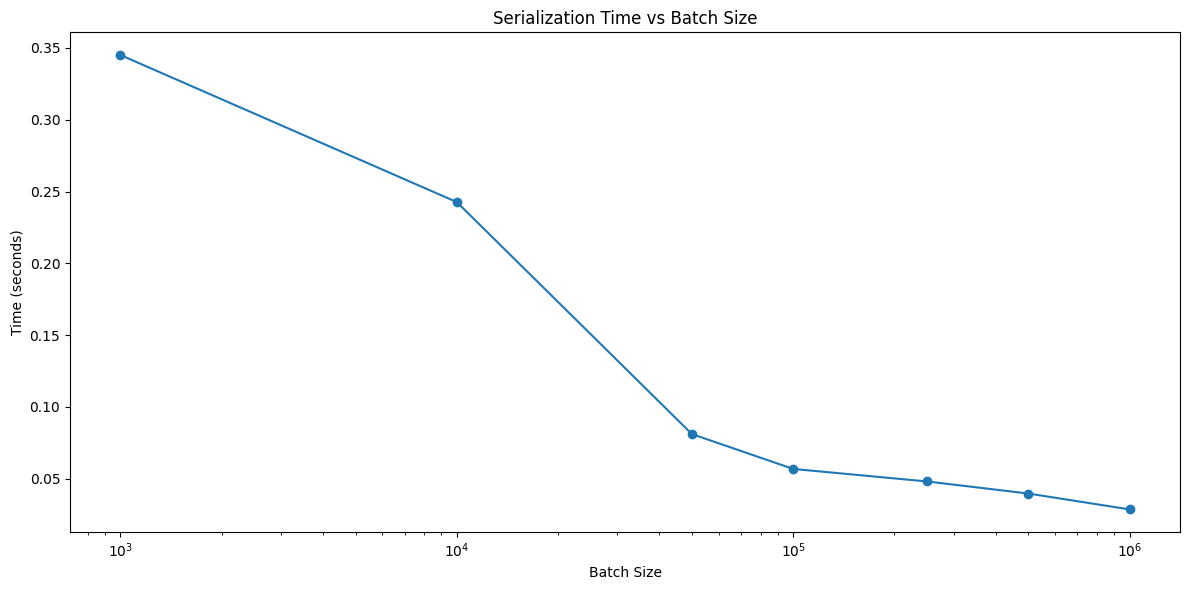

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(
results_df["Batch_Size"],
results_df["Serialization_Time_s"],
marker="o"
)
plt.xscale("log")
plt.title("Serialization Time vs Batch Size")
plt.xlabel("Batch Size")
plt.ylabel("Time (seconds)")
8
plt.tight_layout()
plt.savefig(
GRAPHS_DIR / "serialization_time.png",
dpi=300,
bbox_inches="tight"
)
plt.show()

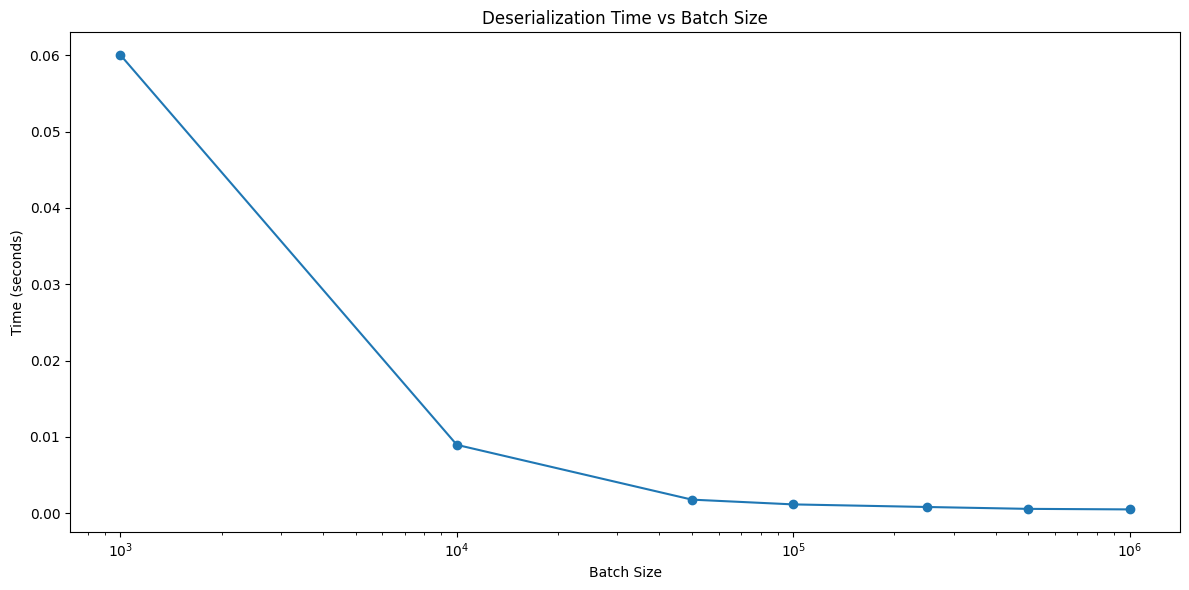

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(
results_df["Batch_Size"],
results_df["Deserialization_Time_s"],
marker="o"
)
plt.xscale("log")
plt.title("Deserialization Time vs Batch Size")
plt.xlabel("Batch Size")
plt.ylabel("Time (seconds)")
plt.tight_layout()
plt.savefig(
GRAPHS_DIR / "deserialization_time.png",
dpi=300,
bbox_inches="tight"
)
plt.show()


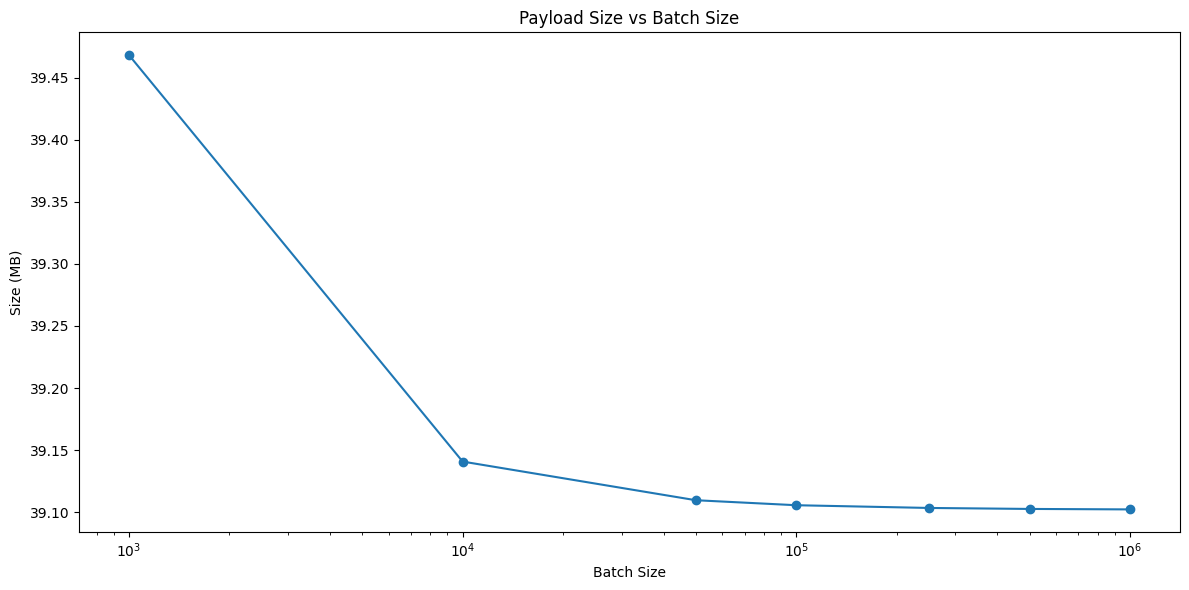

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(
results_df["Batch_Size"],
results_df["Payload_Size_MB"],
marker="o"
)
plt.xscale("log")
plt.title("Payload Size vs Batch Size")
plt.xlabel("Batch Size")
plt.ylabel("Size (MB)")
plt.tight_layout()
plt.savefig(
GRAPHS_DIR / "payload_size.png",
dpi=300,
bbox_inches="tight"
)
plt.show()


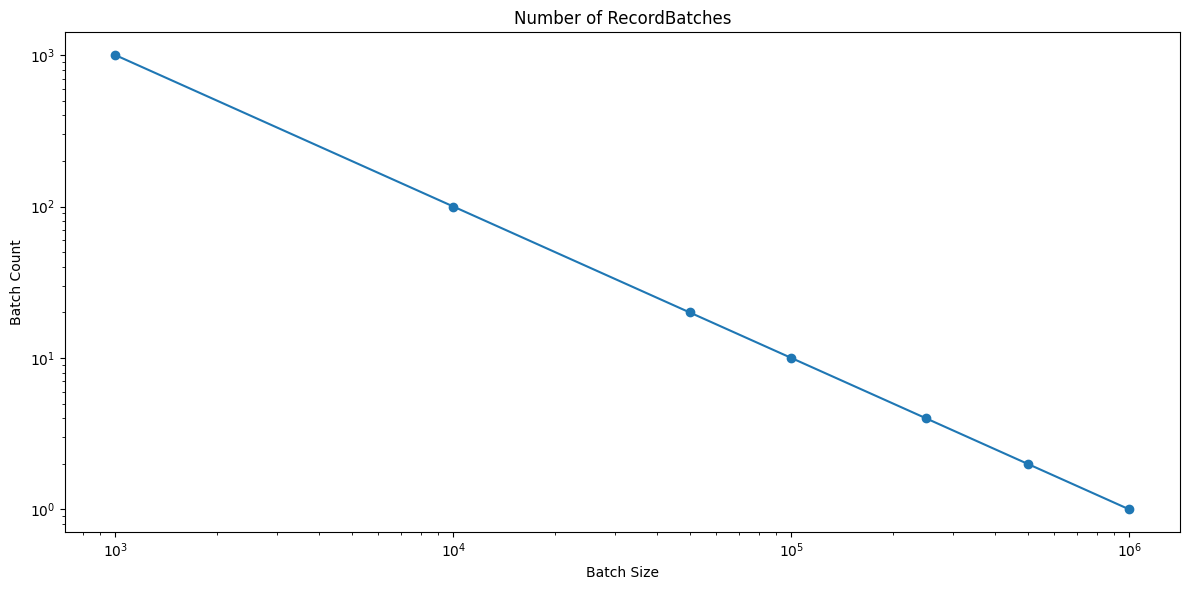

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(
results_df["Batch_Size"],
results_df["Num_Batches"],
marker="o"
)
plt.xscale("log")
plt.yscale("log")
plt.title("Number of RecordBatches")
plt.xlabel("Batch Size")
plt.ylabel("Batch Count")
plt.tight_layout()
plt.savefig(
GRAPHS_DIR / "batch_count.png",
dpi=300,
bbox_inches="tight"
)
plt.show()


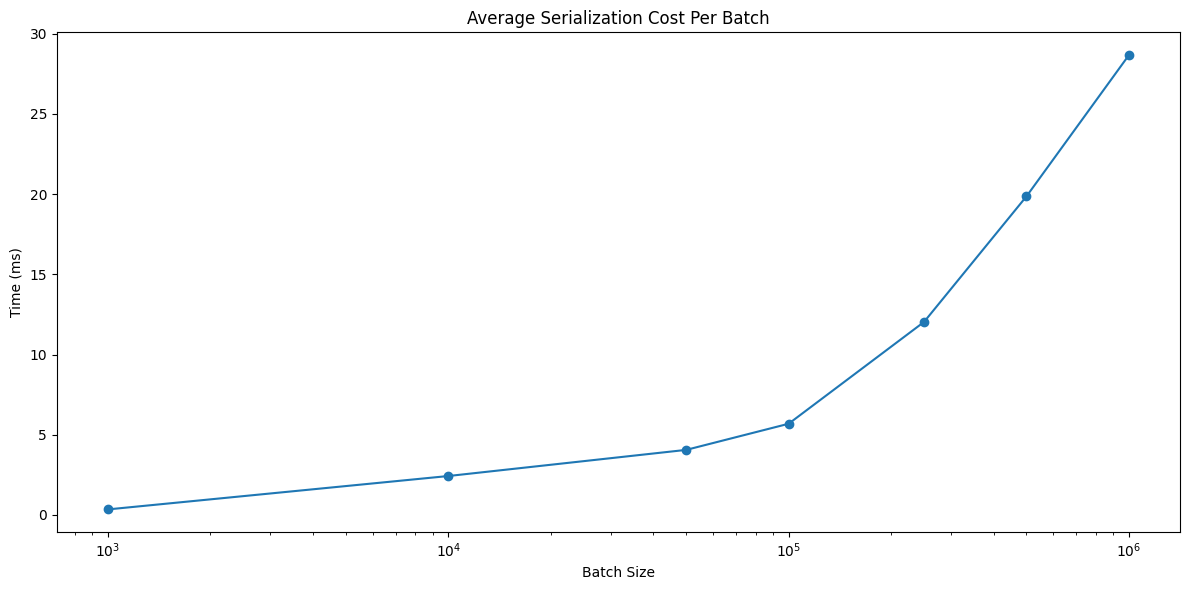

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(
results_df["Batch_Size"],
results_df["Average_Batch_Time_ms"],
marker="o"
)
plt.xscale("log")
plt.title("Average Serialization Cost Per Batch")
plt.xlabel("Batch Size")
plt.ylabel("Time (ms)")
11
plt.tight_layout()
plt.savefig(
GRAPHS_DIR / "average_batch_cost.png",
dpi=300,
bbox_inches="tight"
)
plt.show()


In [16]:
results_csv_path = (
TABLES_DIR /
"batch_effects_results.csv"
)
results_df.to_csv(
results_csv_path,
index=False
)
print(
f"\nResults saved to:\n{results_csv_path}"
)



Results saved to:
/home/megh/arrow-ipc-analysis-linux/results/batch_effects/tables/batch_effects_results.csv


In [18]:
summary_log_path = (
LOGS_DIR /
"summary.txt"
)
with open(summary_log_path, "w") as f:
    f.write("="*80 + "\n")
    f.write("ARROW IPC BATCH EFFECTS EXPERIMENT\n")
    f.write("="*80 + "\n\n")
    f.write(results_df.to_string())
print(
f"\nSummary log saved to:\n{summary_log_path}"
)


Summary log saved to:
/home/megh/arrow-ipc-analysis-linux/results/batch_effects/logs/summary.txt
